<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


This exercise, will focus on the visualization of data. The dataset will be provided through an RDBMS, and will need to use SQL queries to extract the required data.


## Objectives


This exercise, will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite.1’

survey-results-publ 100%[===================>] 201.62M  2.55MB/s    in 73s     
2026-09-05 20:37:17 (2.77 MB/s) - ‘survey-results-public.sqlite.1’ saved [211415040/211415040]


#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 152.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 158.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 146.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 166.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [seaborn]


In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437

#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


       CompTotal
72     2040000.0
374      28000.0
379      85000.0
385      50000.0
389     110000.0
...          ...
65396    36000.0
65401    40000.0
65408    61000.0
65412    58000.0
65431    55000.0

[33740 rows x 1 columns]
14354    1.000000e+150
34278     1.000000e+65
17374     1.000000e+53
8814      1.000000e+44
20037     8.000000e+27
Name: CompTotal, dtype: float64
       CompTotal
374      28000.0
379      85000.0
385      50000.0
389     110000.0
392     126420.0
...          ...
65396    36000.0
65401    40000.0
65408    61000.0
65412    58000.0
65431    55000.0

[29620 rows x 1 columns]

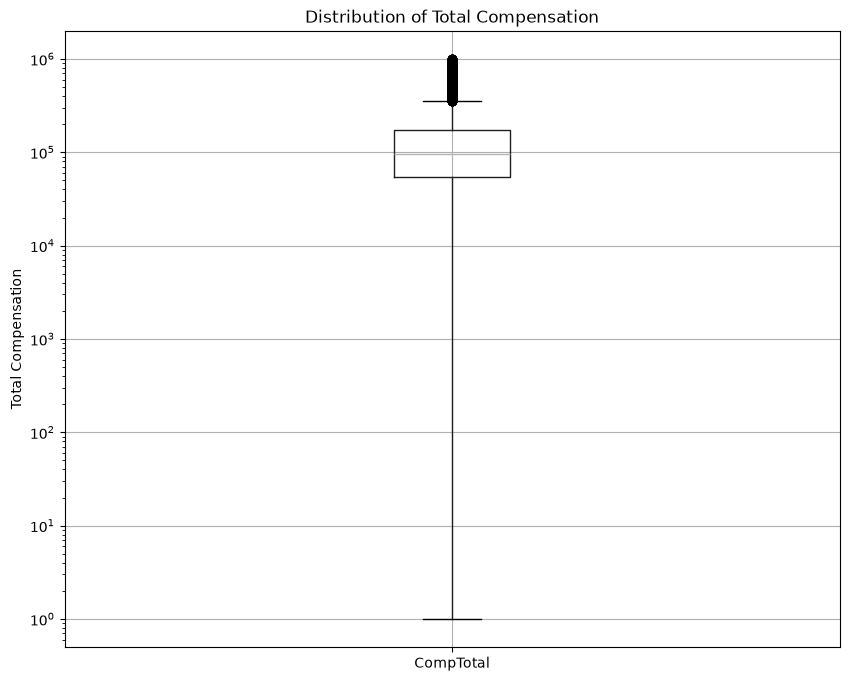

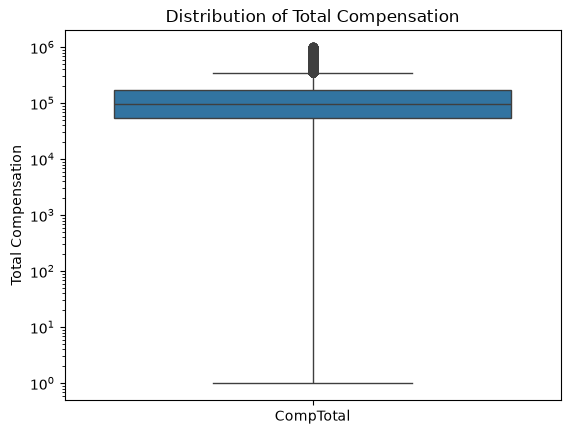

In [8]:
comp_total = "select CompTotal from main"

comp_data= pd.read_sql_query(comp_total, conn).dropna()
print(comp_data)
print(comp_data["CompTotal"].nlargest())
comp_data = comp_data[
            (comp_data["CompTotal"] > 0) &
            (comp_data["CompTotal"] < 1_000_000)
]
print(comp_data)

comp_data.boxplot(column="CompTotal", figsize=(10, 8))
plt.ylabel("Total Compensation")
plt.title("Distribution of Total Compensation")
plt.yscale("log")
plt.show()


sns.boxplot(data=comp_data)
plt.ylabel("Total Compensation")
plt.title("Distribution of Total Compensation")
plt.yscale("log")
plt.show()

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


                      Age
0      Under 18 years old
1         35-44 years old
2         45-54 years old
3         18-24 years old
4         18-24 years old
...                   ...
65432     18-24 years old
65433     25-34 years old
65434     25-34 years old
65435     18-24 years old
65436     18-24 years old

[65437 rows x 1 columns]
0        18.0
1        39.5
2        49.5
3        21.0
4        21.0
         ... 
65432    21.0
65433    29.5
65434    29.5
65435    21.0
65436    21.0
Name: Age, Length: 65437, dtype: float64

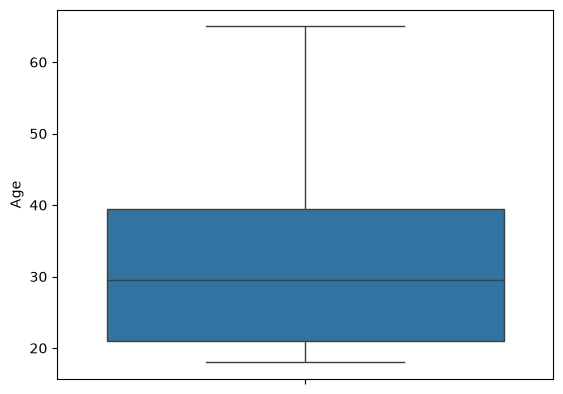

In [9]:
age= "select Age from main"
age_data = pd.read_sql_query(age,conn)
print (age_data)
age_map = {"Under 18 years old":18, "35-44 years old":39.5, "45-54 years old":49.5, "18-24 years old":21, "25-34 years old":29.5,"55-64 years old":59.5, "65 years or older":65}

age_data = age_data["Age"].map(age_map)
print(age_data)

sns.boxplot(data=age_data)
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


       CompTotal              Age
72     2040000.0  18-24 years old
374      28000.0  25-34 years old
379      85000.0  35-44 years old
385      50000.0  35-44 years old
389     110000.0  25-34 years old
...          ...              ...
65396    36000.0  18-24 years old
65401    40000.0  25-34 years old
65408    61000.0  25-34 years old
65412    58000.0  35-44 years old
65431    55000.0  45-54 years old

[33740 rows x 2 columns]

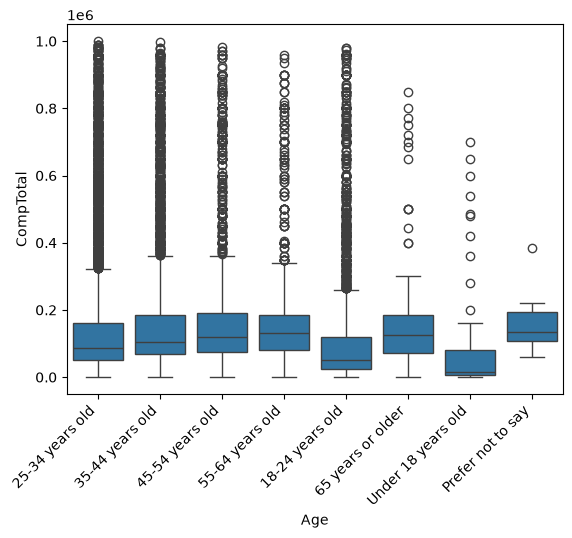

In [15]:
comp_age = "select CompTotal, Age from main"
comp_age_data = pd.read_sql_query(comp_age, conn).dropna()
print (comp_age_data)

comp_age_data = comp_age_data[
            (comp_age_data["CompTotal"] > 0) &
            (comp_age_data["CompTotal"] < 1_000_000)
]

sns.boxplot(data= comp_age_data, x = "Age", y = "CompTotal")
plt.xticks(rotation = 45, ha = "right")
#plt.xscale("log")
plt.show()

""**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


       CompTotal  JobSatPoints_6
72     2040000.0            65.0
379      85000.0             0.0
389     110000.0            20.0
392     126420.0            30.0
398     195000.0            30.0
...          ...             ...
65161    40000.0            20.0
65163    46000.0            50.0
65166    81600.0            20.0
65168   500000.0             0.0
65178    40000.0             0.0

[22478 rows x 2 columns]
       CompTotal  JobSatPoints_6        JobSatPoints
72     2040000.0            65.0      very satisfied
379      85000.0             0.0  slightly satisfied
389     110000.0            20.0  slightly satisfied
392     126420.0            30.0           satisfied
398     195000.0            30.0           satisfied
...          ...             ...                 ...
65161    40000.0            20.0  slightly satisfied
65163    46000.0            50.0           satisfied
65166    81600.0            20.0  slightly satisfied
65168   500000.0             0.0  slightly satis

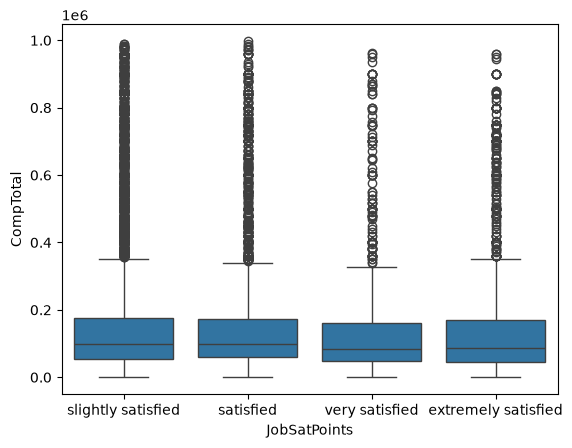

In [10]:
comp_job = "select CompTotal, JobSatPoints_6 from main"
comp_job_data = pd.read_sql_query(comp_job, conn).dropna()
print (comp_job_data)

comp_job_data["JobSatPoints"] = pd.cut(comp_job_data["JobSatPoints_6"], bins = [0,25,50,75,100], labels = ["slightly satisfied", "satisfied", "very satisfied", "extremely satisfied"], include_lowest = True)
print (comp_job_data)
comp_job_data = comp_job_data[
            (comp_job_data["CompTotal"] > 0) &
            (comp_job_data["CompTotal"] < 1_000_000)]

sns.boxplot(data =comp_job_data, y ="CompTotal" , x = "JobSatPoints")
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


       ConvertedCompYearly                                        DevType
72                  7322.0  Data scientist or machine learning specialist
374                30074.0                            Academic researcher
379                91295.0  Data scientist or machine learning specialist
385                53703.0                            Developer, back-end
389               110000.0                                        Student
...                    ...                                            ...
41180              44640.0    Developer, embedded applications or devices
41184             170000.0                                Project manager
41185             116844.0                          Developer, full-stack
41186              12000.0                          Developer, full-stack
41187             222834.0    Developer, embedded applications or devices

[23403 rows x 2 columns]
DevType
Developer                             17718
full-stack                        

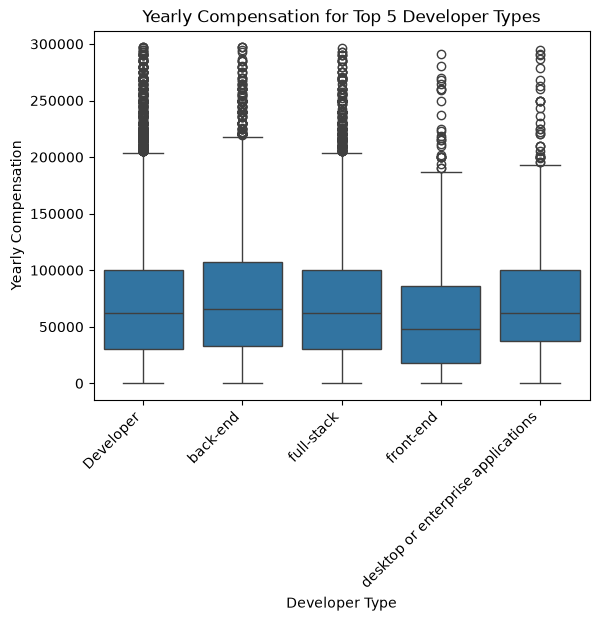

'\ncom_dev_data.boxplot(column= "ConvertedCompYearly")\nplt.show()\n\n'

In [11]:
com_dev = "select ConvertedCompYearly, DevType from main"
com_dev_data = pd.read_sql_query(com_dev, conn).dropna()
print(com_dev_data)
dev_types = com_dev_data["DevType"].str.split(",").explode().str.strip().value_counts().head()
print(dev_types)

plot_data = com_dev_data.copy()
plot_data["DevType"] = plot_data["DevType"].str.split(",")
plot_data = plot_data.explode("DevType")
plot_data["DevType"] = plot_data["DevType"].str.strip()

# Keep only the top 5 developer types
plot_data = plot_data[plot_data["DevType"].isin(dev_types.index)]


print(plot_data)

plot_data  = plot_data [
            (plot_data ["ConvertedCompYearly"] > 0) &
            (plot_data ["ConvertedCompYearly"] < 300_000)]


sns.boxplot(
    data=plot_data,
    x="DevType",
    y="ConvertedCompYearly"
)

plt.xticks(rotation=45, ha= "right")
plt.xlabel("Developer Type")
plt.ylabel("Yearly Compensation")
plt.title("Yearly Compensation for Top 5 Developer Types")
plt.show()

"""
com_dev_data.boxplot(column= "ConvertedCompYearly")
plt.show()

"""

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


       CompTotal                   Country
72     2040000.0                  Pakistan
374      28000.0                   Austria
379      85000.0                    Turkey
385      50000.0                    France
389     110000.0  United States of America
...          ...                       ...
65396    36000.0                 Lithuania
65401    40000.0                    France
65408    61000.0                    France
65412    58000.0                     Italy
65431    55000.0                   Belgium

[33740 rows x 2 columns]
Country
United States of America                                7042
Germany                                                 3004
United Kingdom of Great Britain and Northern Ireland    2008
Ukraine                                                 1610
India                                                   1551
Name: count, dtype: int64
       CompTotal                                            Country
389     110000.0                           United S

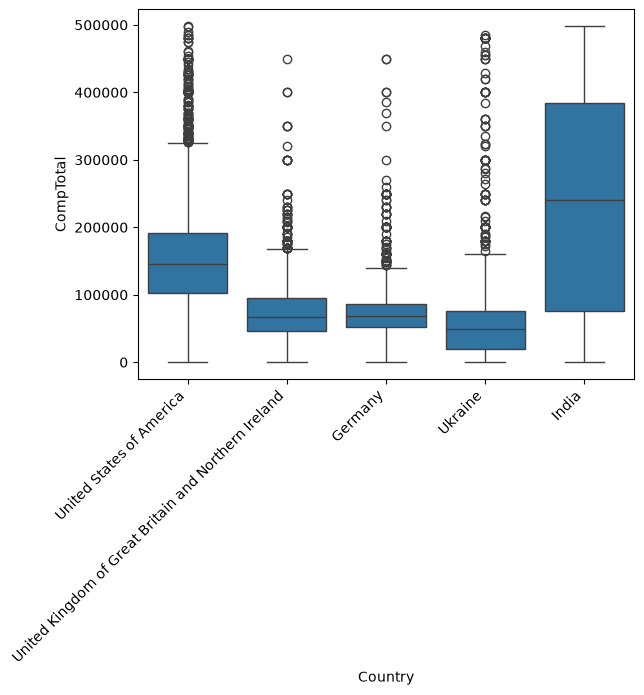

In [12]:
comp_country = "select CompTotal, country from main"
comp_country_data = pd.read_sql_query(comp_country, conn).dropna()
print(comp_country_data)

top_country = comp_country_data["Country"].value_counts().head()
print(top_country)

comp_country_data = comp_country_data[comp_country_data ["Country"].isin(top_country.index)]
print(comp_country_data)

comp_country_data = comp_country_data [
            (comp_country_data ["CompTotal"] > 0) &
            (comp_country_data ["CompTotal"] < 500_000)]

sns.boxplot(data= comp_country_data, x = "Country", y = "CompTotal")
plt.xticks(rotation = 45, ha = "right")
plt.show()


### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


       CompTotal                                         Employment
72     2040000.0  Employed, full-time;Student, full-time;Indepen...
374      28000.0                                Employed, full-time
379      85000.0                                Employed, full-time
385      50000.0  Independent contractor, freelancer, or self-em...
389     110000.0             Employed, full-time;Student, part-time
...          ...                                                ...
65396    36000.0  Employed, full-time;Independent contractor, fr...
65401    40000.0                                Employed, full-time
65408    61000.0                                Employed, full-time
65412    58000.0                                Employed, full-time
65431    55000.0                                Employed, full-time

[33740 rows x 2 columns]

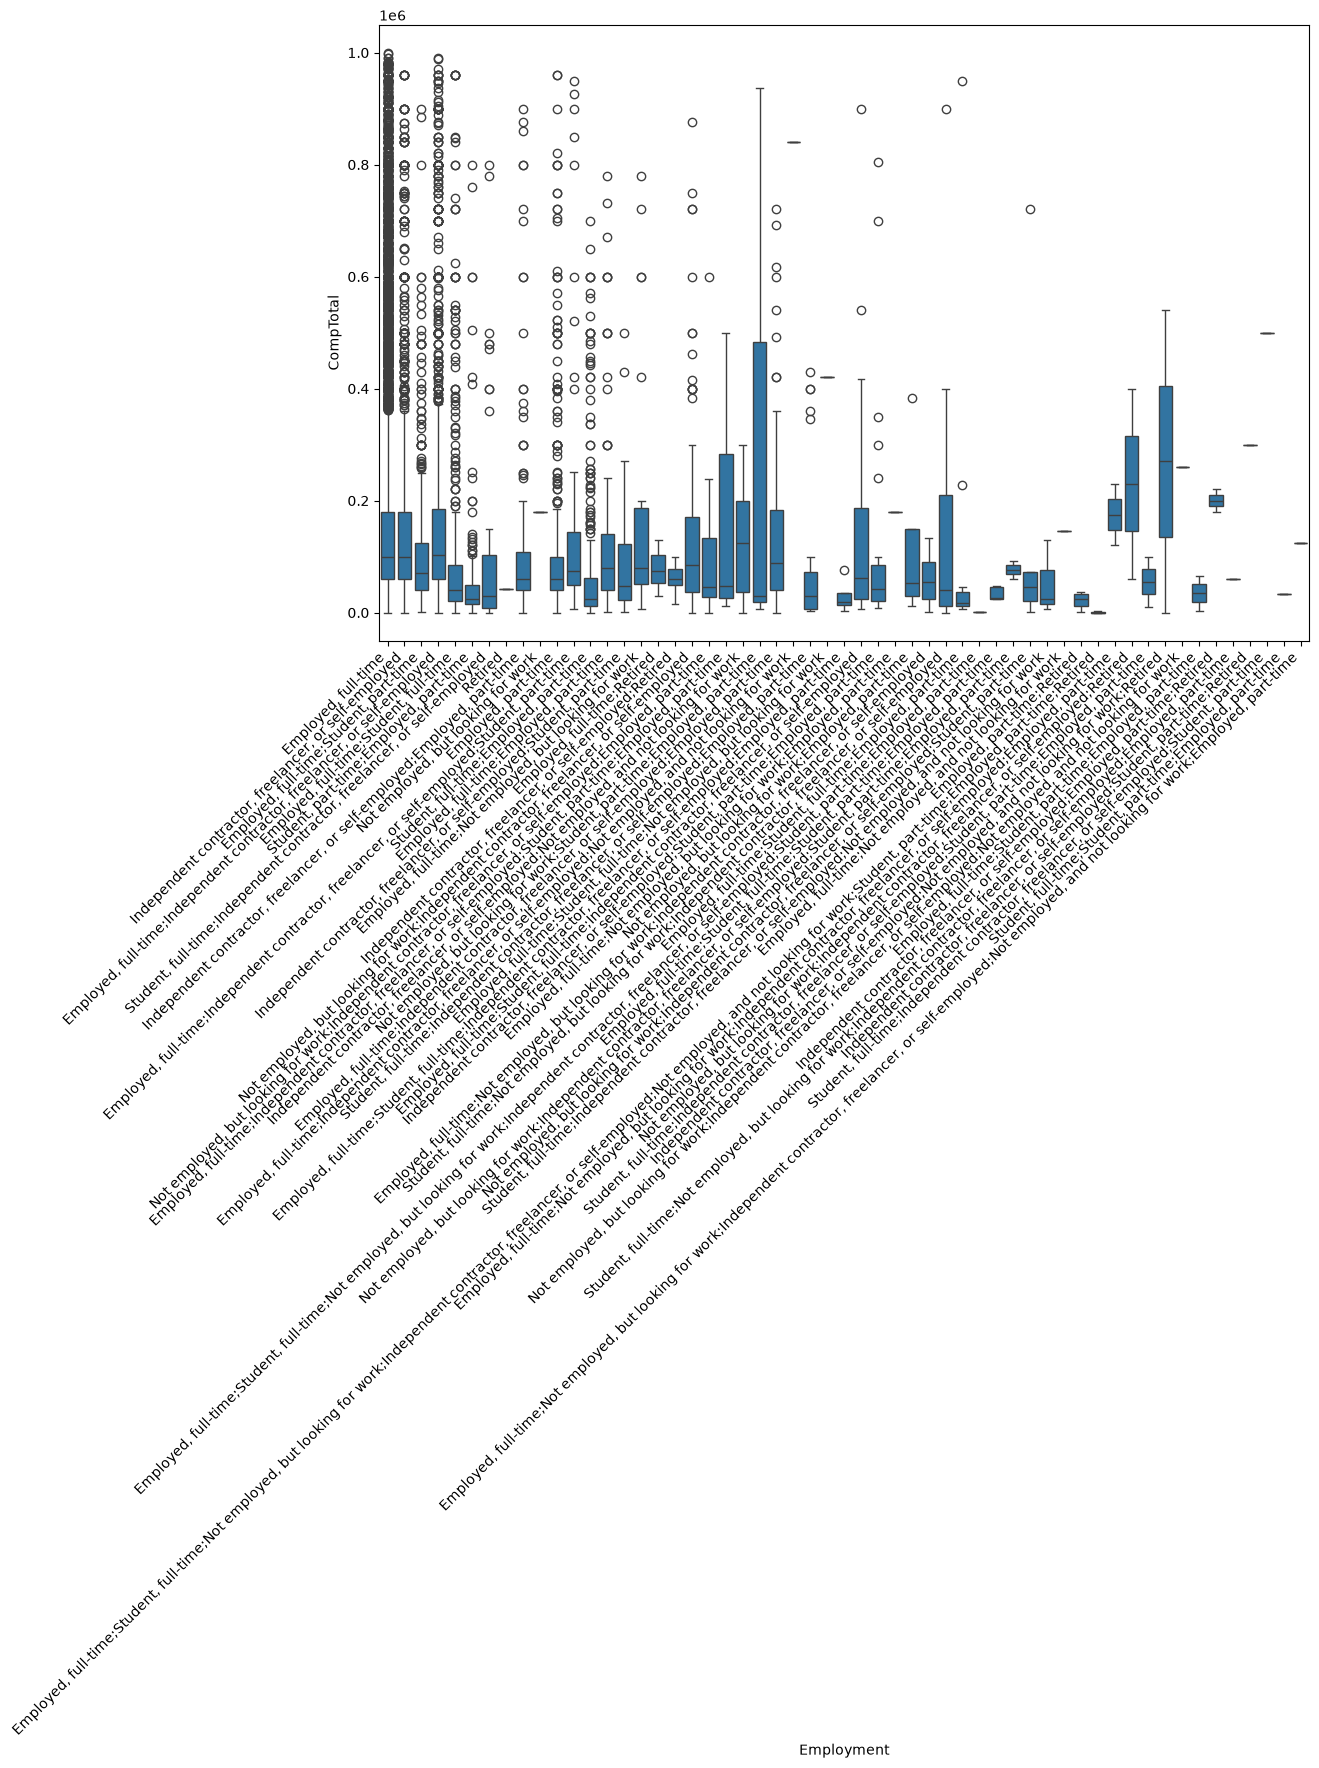

In [13]:
com_employ = "select CompTotal , Employment from main"
com_employ_data = pd.read_sql_query(com_employ, conn).dropna()
print(com_employ_data)

com_employ_data = com_employ_data[
            (com_employ_data ["CompTotal"] > 0) &
            (com_employ_data ["CompTotal"] < 1_000_000)]

plt.figure(figsize=(12, 8))
sns.boxplot(data = com_employ_data, x = "Employment", y = "CompTotal")
plt.xticks(rotation=45, ha="right")
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


           YearsCodePro  JobSatPoints_6
1                    17             0.0
12                   12            30.0
15                   27             0.0
18                   10            60.0
20     Less than 1 year           100.0
...                 ...             ...
65168                 2             0.0
65178                17             0.0
65265                 2            60.0
65351                 7             0.0
65435                 2             0.0

[28619 rows x 2 columns]
       YearsCodePro  JobSatPoints_6
1              17.0             0.0
12             12.0            30.0
15             27.0             0.0
18             10.0            60.0
20              1.0           100.0
...             ...             ...
65168           2.0             0.0
65178          17.0             0.0
65265           2.0            60.0
65351           7.0             0.0
65435           2.0             0.0

[28619 rows x 2 columns]
YearsCodePro          float64
JobSat

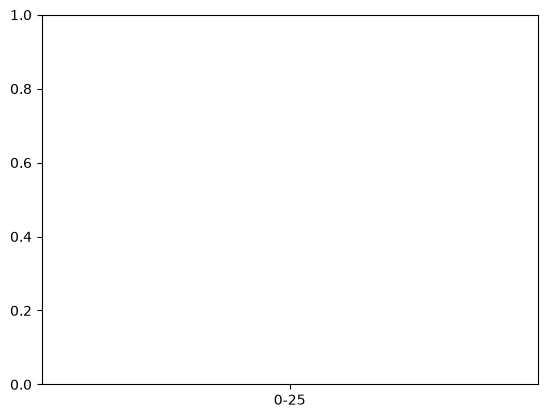

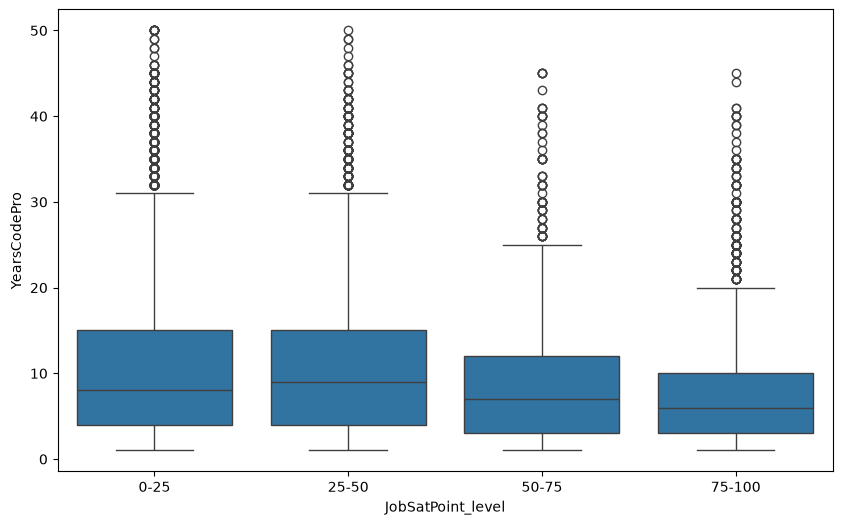

In [106]:
code_pro_sat = "select YearsCodePro, JobSatPoints_6 from main"
code_sat_data = pd.read_sql_query(code_pro_sat, conn).dropna()
print(code_sat_data)

code_sat_data["YearsCodePro"] = code_sat_data["YearsCodePro"].replace({"Less than 1 year":1.0, "More than 50 years":50.0})
code_sat_data["YearsCodePro"] = pd.to_numeric(code_sat_data["YearsCodePro"], errors = "coerce")

print(code_sat_data)

code_sat_data["JobSatPoints_6"] = pd.to_numeric(
    code_sat_data["JobSatPoints_6"],
    errors="coerce"
)
code_sat_data["JobSatPoint_level"] = pd.cut(code_sat_data["JobSatPoints_6"], bins = [0, 25, 50,75,100], labels = ["0-25","25-50","50-75","75-100"], include_lowest=True)
code_sat_data = code_sat_data.dropna()
print(code_sat_data.dtypes)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=code_sat_data,
    x="JobSatPoint_level",
    y="YearsCodePro"
)

plt.show()

### Final Step: Close the Database Connection


In [107]:
conn.close()

## Summary


In this exercise, used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
